## Packages 

penser à installer les packages:
pip install pandas matplotlib scikit-learn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import os

## Chargement des données

In [2]:
os.getcwd()

'c:\\Users\\gevab\\city_lifestyle\\notebooks'

In [3]:
df = pd.read_csv("../data/city_lifestyle_dataset.csv")

### description rapides : 

In [4]:
print(df.head())
print(df.describe())
print(df.info())

       city_name country  population_density  avg_income  \
0      Old Vista  Europe                2775        3850   
1      Beachport  Europe                3861        3700   
2  Valleyborough  Europe                2562        4310   
3           City  Europe                3192        3970   
4          Falls  Europe                3496        4320   

   internet_penetration  avg_rent  air_quality_index  public_transport_score  \
0                  86.4      1310                 43                    52.0   
1                  78.1      1330                 42                    62.8   
2                  80.1      1330                 39                    73.2   
3                  81.2      1480                 60                    49.2   
4                 100.0      1510                 64                    93.7   

   happiness_score  green_space_ratio  
0              8.5               23.8  
1              8.1               33.1  
2              8.5               40.2 

## Variables numériques
On ne garde ici que les variables numériques

In [5]:
X = df.select_dtypes(include=['float64', 'int64'])
X

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,3496,4320,100.0,1510,64,93.7,8.5,42.5
...,...,...,...,...,...,...,...,...
295,1004,4620,100.0,1500,40,64.2,8.5,50.2
296,1652,4500,100.0,1650,44,49.3,8.5,37.4
297,836,3910,98.7,1340,40,55.7,8.5,38.6
298,758,3490,91.2,1390,36,54.1,8.5,44.6


## Standardisation

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-3.92882389e-01,  8.52930151e-01,  7.12032705e-01, ...,
        -2.53086289e-01,  1.10275857e+00, -1.08228661e+00],
       [-2.81581030e-02,  7.27842624e-01,  2.23398201e-01, ...,
         4.82207450e-01,  8.65095083e-01, -9.48504942e-02],
       [-4.64416710e-01,  1.23653190e+00,  3.41141455e-01, ...,
         1.19026809e+00,  1.10275857e+00,  6.58998583e-01],
       ...,
       [-1.04407980e+00,  9.02965162e-01,  1.43615372e+00, ...,
        -1.18010106e-03,  1.10275857e+00,  4.89117101e-01],
       [-1.07027547e+00,  5.52720086e-01,  9.94616515e-01, ...,
        -1.10112507e-01,  1.10275857e+00,  1.12617266e+00],
       [-9.10078890e-01,  1.25321024e+00,  7.12032705e-01, ...,
         1.33324187e+00,  1.10275857e+00,  6.27145805e-01]],
      shape=(300, 8))

## Application de la méthode t-SNE


In [7]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)
tsne

,"n_components n_components: int, default=2Dimension of the embedded space.",2
,"perplexity perplexity: float, default=30.0The perplexity is related to the number of nearest neighbors thatis used in other manifold learning algorithms. Larger datasetsusually require a larger perplexity. Consider selecting a valuebetween 5 and 50. Different values can result in significantlydifferent results. The perplexity must be less than the numberof samples.",30
,"early_exaggeration early_exaggeration: float, default=12.0Controls how tight natural clusters in the original space are inthe embedded space and how much space will be between them. Forlarger values, the space between natural clusters will be largerin the embedded space. Again, the choice of this parameter is notvery critical. If the cost function increases during initialoptimization, the early exaggeration factor or the learning ratemight be too high.",12.0
,"learning_rate learning_rate: float or ""auto"", default=""auto""The learning rate for t-SNE is usually in the range [10.0, 1000.0]. Ifthe learning rate is too high, the data may look like a 'ball' with anypoint approximately equidistant from its nearest neighbours. If thelearning rate is too low, most points may look compressed in a densecloud with few outliers. If the cost function gets stuck in a bad localminimum increasing the learning rate may help.Note that many other t-SNE implementations (bhtsne, FIt-SNE, openTSNE,etc.) use a definition of learning_rate that is 4 times smaller thanours. So our learning_rate=200 corresponds to learning_rate=800 inthose other implementations. The 'auto' option sets the learning_rateto `max(N / early_exaggeration / 4, 50)` where N is the sample size,following [4] and [5]... versionchanged:: 1.2 The default value changed to `""auto""`.",200
,"max_iter max_iter: int, default=1000Maximum number of iterations for the optimization. Should be atleast 250... versionchanged:: 1.5 Parameter name changed from `n_iter` to `max_iter`.",1000
,"n_iter_without_progress n_iter_without_progress: int, default=300Maximum number of iterations without progress before we abort theoptimization, used after 250 initial iterations with earlyexaggeration. Note that progress is only checked every 50 iterations sothis value is rounded to the next multiple of 50... versionadded:: 0.17 parameter *n_iter_without_progress* to control stopping criteria.",300
,"min_grad_norm min_grad_norm: float, default=1e-7If the gradient norm is below this threshold, the optimization willbe stopped.",1e-07
,"metric metric: str or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string, it must be one of the optionsallowed by scipy.spatial.distance.pdist for its metric parameter, ora metric listed in pairwise.PAIRWISE_DISTANCE_FUNCTIONS.If metric is ""precomputed"", X is assumed to be a distance matrix.Alternatively, if metric is a callable function, it is called on eachpair of instances (rows) and the resulting value recorded. The callableshould take two arrays from X as input and return a value indicatingthe distance between them. The default is ""euclidean"" which isinterpreted as squared euclidean distance.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 1.1",None
,"init init: {""random"", ""pca""} or ndarray of shape (n_samples, n_components), default=""pca""Initialization of embedding.PCA initialization cannot be used with precomputed distances and isusually more globally stable than random initialization... versionchanged:: 1.2 The default value changed to `""pca""`.",'pca'
,"verbose verbose: int, default=0Verbosity level.",0


In [8]:
X_tsne = tsne.fit_transform(X_scaled)
X_tsne

array([[-1.24656296e+00,  1.33966026e+01],
       [-3.88020086e+00,  5.60037422e+00],
       [-9.04310036e+00,  1.15551987e+01],
       [-1.56315136e+00,  7.81306362e+00],
       [-1.31231365e+01,  1.14214811e+01],
       [-8.50808203e-01,  1.47781210e+01],
       [-1.57019570e-01,  7.60253096e+00],
       [-4.66335392e+00,  7.13042879e+00],
       [-7.10666752e+00,  1.69582558e+01],
       [-2.24576044e+00,  2.11418343e+00],
       [ 2.64071155e+00,  2.09587860e+00],
       [-3.49425673e+00,  4.64533377e+00],
       [-1.28180563e+00,  3.41925454e+00],
       [ 8.65918446e+00, -8.65855217e+00],
       [-5.79363060e+00,  4.70943594e+00],
       [-1.14807396e+01,  1.43581057e+01],
       [-2.31780306e-01, -3.16767883e+00],
       [ 2.98237896e+00,  3.11751890e+00],
       [ 1.96823215e+00,  6.41247332e-01],
       [ 5.03363657e+00,  4.72516823e+00],
       [ 3.48783755e+00,  4.96240091e+00],
       [-1.19102609e+00,  7.08705044e+00],
       [-5.95600319e+00,  1.44099140e+01],
       [ 1.

## Visualisation

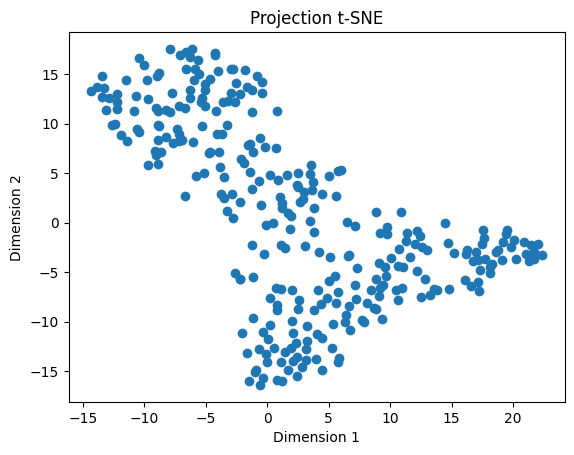

In [9]:
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1])
plt.title("Projection t-SNE")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

La projection nous montre que les données ne sont pas réparties de façon aléatoire. 
On observe plusieurs regroupements distincts, ce qui peut indiquer l’existence de sous-groupes naturels au sein des données.

Les points proches dans la projection partagent des caractéristiques similaires dans l’espace initial, tandis que les zones séparées traduisent des différences  manquantes entre certains ensembles d’observations.

La forme non linéaire de la distribution indique que la structure des données est complexe .

## Export des données

In [10]:
# Création du DataFrame des embeddings
emb_df = pd.DataFrame(X_tsne, columns=["tsne_1", "tsne_2"])

# Export
emb_df.to_csv("../outputs/tsne_embeddings.csv", index=False)

print("Fichier exporté : tsne_embeddings.csv")

Fichier exporté : tsne_embeddings.csv
